* Data Ingestion

In [1]:
# Import fucntions
import pandas as pd
import numpy as np

# Load and Inspect Dataset
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(df.head(10))
print(df.shape)
print(df.dtypes)
print(df.describe()) #Gave statistical summary
print(df.describe(include="object"))
print(df.isna().sum())
print(df.nunique())


   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   
5   32        No  Travel_Frequently       1005  Research & Development   
6   59        No      Travel_Rarely       1324  Research & Development   
7   30        No      Travel_Rarely       1358  Research & Development   
8   38        No  Travel_Frequently        216  Research & Development   
9   36        No      Travel_Rarely       1299  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8      

In [2]:
print(df.duplicated().sum())
df.drop_duplicates()

0


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [3]:
# Classification - checking class balance
print(df["Attrition"].value_counts())
print(df["Attrition"].value_counts(normalize=True))

#Regression
# print(df["Attrition"].describe())
# df["Attrition"].hist(bins=30) #check if it skewd ? are the outlier? 

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


* Exploratory Data Analysis (EDA) 

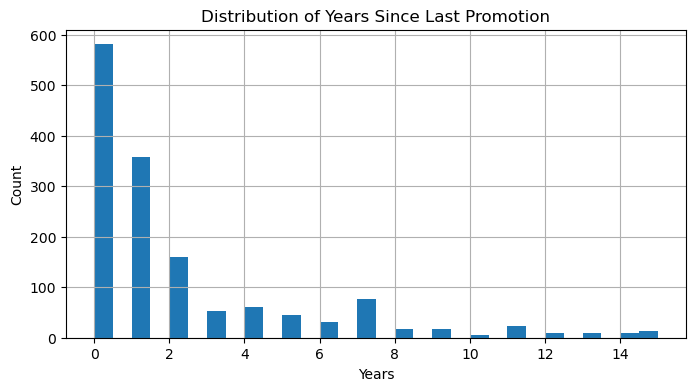

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

#histogram - to understand distribution
df["YearsSinceLastPromotion"].hist(bins=30,figsize=(8,4))
plt.title("Distribution of Years Since Last Promotion")
plt.xlabel("Years"); plt.ylabel("Count");plt.show()


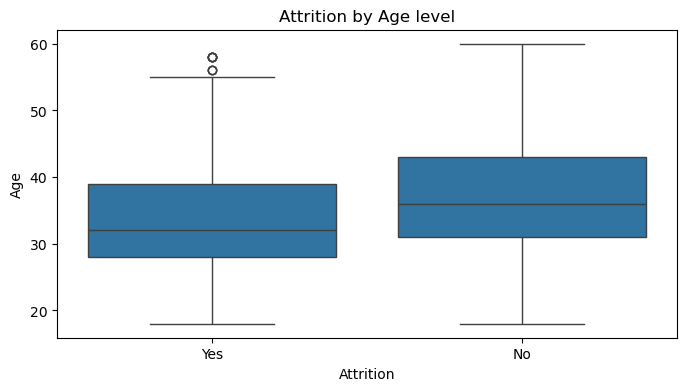

In [5]:
#boxplot - to see median, quartiles, and outliers 
plt.figure(figsize=(8,4))
sns.boxplot(x="Attrition",y="Age",data=df)
plt.title("Attrition by Age level")
plt.show()


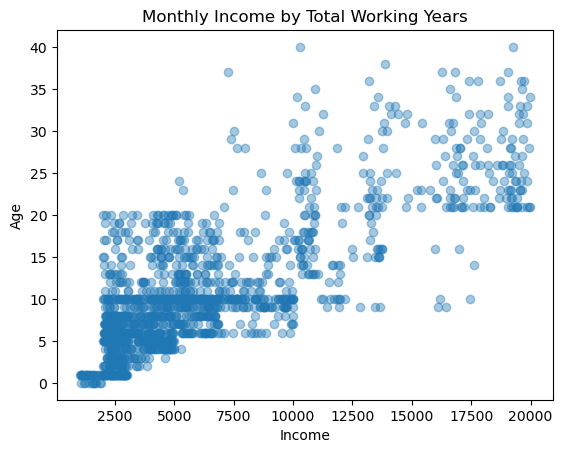

<Axes: xlabel='MonthlyIncome', ylabel='TotalWorkingYears'>

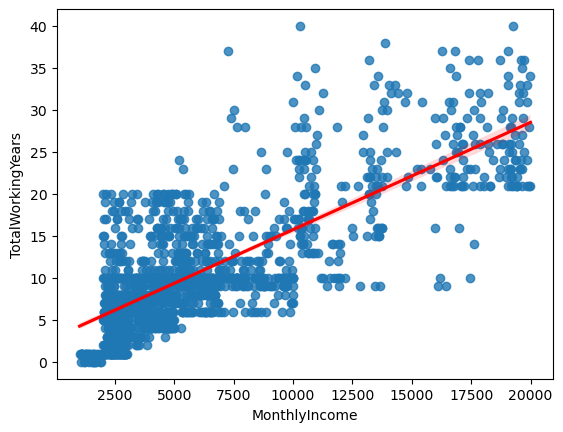

In [6]:
#Scatter plot - relationship between 2 numerical variables
plt.scatter(df["MonthlyIncome"],df["TotalWorkingYears"],alpha=0.4)
plt.xlabel("Income");plt.ylabel("Age")
plt.title("Monthly Income by Total Working Years")
plt.show()

# Regression line - show direction of correlation ; if upword slope = postivie correlation
sns.regplot(x="MonthlyIncome",y="TotalWorkingYears",data=df,line_kws={'color': 'red'})

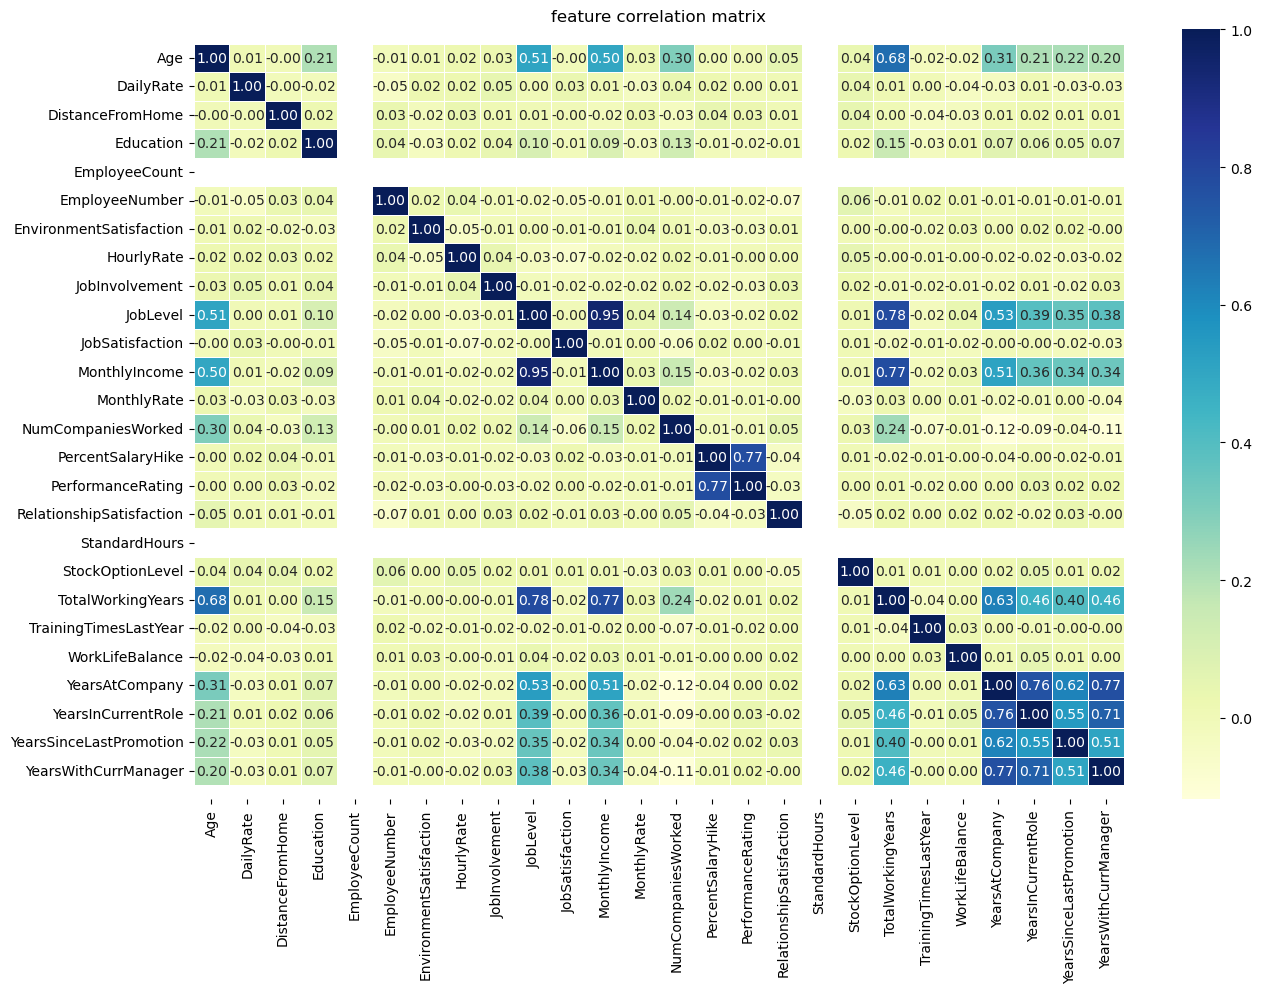

In [7]:
# Correlation Heatmap - see all relationship
corr = df.select_dtypes(include="number").corr()

fig,ax=plt.subplots(figsize=(15,10))
ax=sns.heatmap(corr,annot=True,linewidths=0.5,fmt=".2f",cmap="YlGnBu")
bottom,top=ax.get_ylim()
ax.set_ylim(bottom+0.5,top-0.5)

plt.title("feature correlation matrix")
plt.show()


* Data Cleaning

In [8]:
# Handle null values, depends on how many missing values, importance of the column, dataset size 
df.isna().sum()
df.dropna(inplace=True)

# to drop column , df.drop(columns=["x"],inplace=True)

In [9]:
#Handle duplicates
df.drop_duplicates(inplace=True)

In [10]:
#Outlier detection -if have <500 : may lose too much data
# IQR Method

def remove_outlier_iqr(df,col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(df)
    df_clean = df[(df[col]>=lower)&(df[col]<=upper)]
    print(f"{col}: removed {before - len(df_clean)} ourlier rows")
    return df_clean

<Axes: xlabel='MonthlyIncome'>

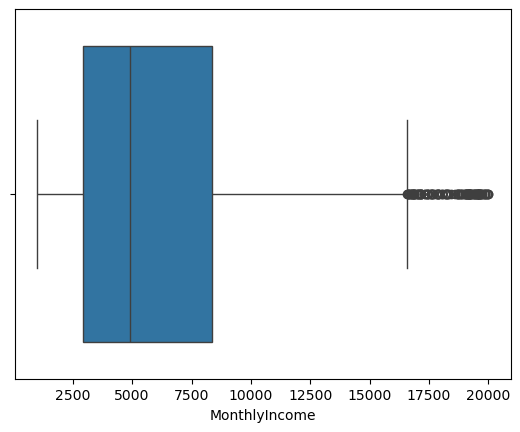

In [11]:
sns.boxplot(x=df["MonthlyIncome"])

* Feature Engineering - transforming raw data into better input features for the model

In [12]:
# Extract from dates
# df['hour']        = df['created_at'].dt.hour
# df['day_of_week'] = df['created_at'].dt.dayofweek   # 0=Mon, 6=Sun
# df['month']       = df['created_at'].dt.month
# df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)

* Train / Test Split

In [13]:
# Standard train/test, train/val/test, crossvalidation
# stratify=y helps train and test preserve ratios 
# random_state is to make sure model use the same train test split 

# 1. Drop useless columns
df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'], inplace=True)

# 2. Map binary target — this is just renaming
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['OverTime']  = df['OverTime'].map({'Yes': 1, 'No': 0})
df['Gender']    = df['Gender'].map({'Male': 1, 'Female': 0})

from sklearn.model_selection import train_test_split
x = df.drop(columns="Attrition")
y = df["Attrition"]

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=42,
                                                stratify=y)
print(f"Train: {x_train.shape}, Test: {x_test.shape}")
print(f"Train class balance: {y_train.value_counts(normalize=True)}")
print(f"Train class balance: {y_test.value_counts(normalize=True)}")

Train: (1176, 30), Test: (294, 30)
Train class balance: Attrition
0    0.838435
1    0.161565
Name: proportion, dtype: float64
Train class balance: Attrition
0    0.840136
1    0.159864
Name: proportion, dtype: float64


* Preprocessing

In [14]:
# Impute missing values
# from sklearn.impute import SimpleImputer

# 1. Initialize the imputers
# numerical_imp = SimpleImputer(strategy="median")
# categorical_imp = SimpleImputer(strategy="most_frequent")

# 2. Column names (using .columns)
# num_cols = x_train.select_dtypes(include="number").columns
# cat_cols = x_train.select_dtypes(include="object").columns

# 3. Impute Numerical Columns
# x_train[num_cols] = numerical_imp.fit_transform(x_train[num_cols])
# x_test[num_cols] = numerical_imp.transform(x_test[num_cols])

# 4. Impute Categorical Columns (Don't forget to apply these too!)
# x_train[cat_cols] = categorical_imp.fit_transform(x_train[cat_cols])
# x_test[cat_cols] = categorical_imp.transform(x_test[cat_cols])

In [15]:
x_train["BusinessTravel"].value_counts()

BusinessTravel
Travel_Rarely        828
Travel_Frequently    225
Non-Travel           123
Name: count, dtype: int64

In [16]:
# Encoding - if nunique()==1, just drop the table 
# there are 3 types 
# 1) Label Encoding - for binary 0,1.. Unique have 2 only 
# 2) Ordinal Encoding - for rankings 
# 3) One-Hot Encoding - for normal category 
# 4) pd.get_dummies (quick one-liner for notebooks)

from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, OneHotEncoder, StandardScaler

#Ordinal Encoding
ord_enc = OrdinalEncoder(categories=[["Non-Travel","Travel_Rarely","Travel_Frequently"]])
x_train["BusinessTravel"]=ord_enc.fit_transform(x_train[["BusinessTravel"]])
x_test["BusinessTravel"]=ord_enc.transform(x_test[["BusinessTravel"]])

#OneHotEncoding
ohe_cols = x_train.select_dtypes(include=["object","category"]).columns.tolist()
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
ohe_train = ohe.fit_transform(x_train[ohe_cols])
ohe_feature_names = ohe.get_feature_names_out(ohe_cols)
ohe_test = ohe.transform(x_test[ohe_cols])

x_train = pd.concat([
    x_train.drop(columns=ohe_cols).reset_index(drop=True),
    pd.DataFrame(ohe_train, columns=ohe_feature_names)
], axis=1)

x_test = pd.concat([
    x_test.drop(columns=ohe_cols).reset_index(drop=True),
    pd.DataFrame(ohe_test, columns=ohe_feature_names)
], axis=1)

print(x_train.dtypes)

Age                                    int64
BusinessTravel                       float64
DailyRate                              int64
DistanceFromHome                       int64
Education                              int64
EnvironmentSatisfaction                int64
Gender                                 int64
HourlyRate                             int64
JobInvolvement                         int64
JobLevel                               int64
JobSatisfaction                        int64
MonthlyIncome                          int64
MonthlyRate                            int64
NumCompaniesWorked                     int64
OverTime                               int64
PercentSalaryHike                      int64
PerformanceRating                      int64
RelationshipSatisfaction               int64
StockOptionLevel                       int64
TotalWorkingYears                      int64
TrainingTimesLastYear                  int64
WorkLifeBalance                        int64
YearsAtCom

In [17]:
# Feature scaling - 3 types : 1) Standard scaler - linear model svm,pca 2) MinMaxScaler - neural nets, KNN 3) RobustScaler - best when have extreame outlier
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test  = scaler.transform(x_test)

print("X_train shape:", x_train.shape)
print("X_test shape: ", x_test.shape)

X_train shape: (1176, 47)
X_test shape:  (294, 47)


* Balance Dataset

In [19]:
# if minority group < 20% - we need to balance the dataset- only on training set
# if minority 20% to 50% - use classweight
print(y_train.value_counts(normalize=True))

Attrition
0    0.838435
1    0.161565
Name: proportion, dtype: float64


In [22]:
pip install imblearn


   ---------------------------------------- 0/3 [sklearn-compat]
   ---------------------------------------- 0/3 [sklearn-compat]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn

In [23]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

#Basic Smote - create a syntehtic example of minority clasess
sm = SMOTE(random_state=42, k_neighbors=5)
x_train_sm,y_train_sm = sm.fit_resample(x_train,y_train)
print(f"before: {y_train.value_counts().to_dict()}")
print(f"after: {pd.Series(y_train_sm).value_counts().to_dict()}")

# SMOTETomek — oversample minority + undersample majority (best of both)
# smt = SMOTETomek(random_state=42)
# x_train_smt, y_train_smt = smt.fit_resample(x_train, y_train)

#Undersampling
# from imblearn.under_sampling import RandomUnderSampler
# rus = RandomUnderSampler(random_state=42)
# X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)
# WARNING: throws away majority class data — only use if you have lots of data



before: {0: 986, 1: 190}
after: {0: 986, 1: 986}


In [28]:
print(f"Original : {x_train.shape}")
print(f"Smote : {x_train_sm.shape}")

Original : (1176, 47)
Smote : (1972, 47)


* Model Training

In [31]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 3.1/101.7 MB 19.0 MB/s eta 0:00:06
   --- ------------------------------------ 8.9/101.7 MB 24.1 MB/s eta 0:00:04
   ------ --------------------------------- 16.5/101.7 MB 28.8 MB/s eta 0:00:03
   ---------- ----------------------------- 25.7/101.7 MB 32.9 MB/s eta 0:00:03
   ----------- ---------------------------- 30.4/101.7 MB 30.7 MB/s eta 0:00:03
   ------------ --------------------------- 33.0/101.7 MB 27.5 MB/s eta 0:00:03
   -------------- ------------------------- 35.9/101.7 MB 25.5 MB/s eta 0:00:03
   -------------- ------------------------- 37.2/101.7 MB 23.3 MB/s eta 0:00:03
   --------------- ------------------------ 39.1/101.7 MB 21.6 MB/s eta 0:00:03
   ---------------- ----------------------- 41.2/101.7 MB 20.3 MB/s eta 0:00:03
   ----------------- ---------------------- 43.3/101.7 MB 19.4 MB/s eta 0:00:04
   ----------------- ---------------------- 45.4/10

In [44]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb

models={
    "LogisticRegression" : LogisticRegression(max_iter=1000),
    "RandomForestClassifier" : RandomForestClassifier(n_estimators=100),
    "DecisionTree" : DecisionTreeClassifier(),
    "SVC" : SVC(),
    "KNeighborsClassifier" : KNeighborsClassifier(),
}

def fit_score(x_train,y_train,x_test,y_test,models):
    results={}
    np.random.seed(42)
    for name,model in models.items():
        model.fit(x_train,y_train)
        results[name]=model.score(x_test,y_test)
    return results

print("Results with SMOTE")
results_sm = fit_score(x_train_sm,y_train_sm,x_test,y_test,models)
results_sm


Results with SMOTE


{'LogisticRegression': 0.7755102040816326,
 'RandomForestClassifier': 0.8401360544217688,
 'DecisionTree': 0.7755102040816326,
 'SVC': 0.826530612244898,
 'KNeighborsClassifier': 0.6190476190476191}

In [45]:
print("Result without SMOTE")
results = fit_score(x_train,y_train,x_test,y_test,models)
results

Result without SMOTE


{'LogisticRegression': 0.8605442176870748,
 'RandomForestClassifier': 0.8367346938775511,
 'DecisionTree': 0.7857142857142857,
 'SVC': 0.8639455782312925,
 'KNeighborsClassifier': 0.8537414965986394}

In [46]:
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import cross_val_score

results = []
for name, model in models.items():
    cv_scores = cross_val_score(model, x_train, y_train, cv=5, scoring='f1_weighted')
    results.append({'Model': name, 'CV F1 Mean': cv_scores.mean(),
                    'CV F1 Std': cv_scores.std()})

results_df = pd.DataFrame(results).sort_values('CV F1 Mean', ascending=False)
print(results_df)

                    Model  CV F1 Mean  CV F1 Std
0      LogisticRegression    0.872632   0.012437
3                     SVC    0.831942   0.011637
1  RandomForestClassifier    0.825934   0.020716
4    KNeighborsClassifier    0.816375   0.014908
2            DecisionTree    0.781361   0.017359


* Hyperparameter Tuning

In [60]:
lo_grid={
    "C":np.logspace(-4,4,20),
    "solver":["liblinear"]
}
np.random.seed(42)
rs_log=RandomizedSearchCV(LogisticRegression(),
                         param_distributions=lo_grid,
                         cv=5,
                         n_iter=10,
                         verbose=True)
rs_log.fit(x_train,y_train)
print("Best params:", rs_log.best_params_)
print("Best CV F1: ", round(rs_log.best_score_, 4))


rs_log_sm=RandomizedSearchCV(LogisticRegression(),
                         param_distributions=lo_grid,
                         cv=5,
                         n_iter=10,
                         verbose=True)
rs_log_sm.fit(x_train_sm,y_train_sm) #smote
print("Best params:", rs_log_sm.best_params_)
print("Best CV F1: ", round(rs_log_sm.best_score_, 4))


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'solver': 'liblinear', 'C': np.float64(0.23357214690901212)}
Best CV F1:  0.8844
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'solver': 'liblinear', 'C': np.float64(206.913808111479)}
Best CV F1:  0.8094


In [61]:
rs_log.best_params_

{'solver': 'liblinear', 'C': np.float64(0.23357214690901212)}

In [57]:
y_pred = rs_log.predict(x_test)
y_prob = rs_log.predict_proba(x_test)[:,1]
print(classification_report(y_test, y_pred, target_names=['No','Yes']))
print("AUC-ROC:", round(roc_auc_score(y_test, y_prob), 4))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion matrix:")
print(cm)

              precision    recall  f1-score   support

          No       0.88      0.96      0.92       247
         Yes       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294

AUC-ROC: 0.8078

Confusion matrix:
[[237  10]
 [ 31  16]]


In [63]:
y_pred = rs_log_sm.predict(x_test)
y_prob = rs_log_sm.predict_proba(x_test)[:,1]
print(classification_report(y_test, y_pred, target_names=['No','Yes']))
print("AUC-ROC:", round(roc_auc_score(y_test, y_prob), 4))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion matrix:")
print(cm)

              precision    recall  f1-score   support

          No       0.91      0.81      0.86       247
         Yes       0.37      0.60      0.46        47

    accuracy                           0.78       294
   macro avg       0.64      0.70      0.66       294
weighted avg       0.83      0.78      0.79       294

AUC-ROC: 0.7912

Confusion matrix:
[[200  47]
 [ 19  28]]


* Model Evaluation

In [64]:
# Binary Classification
from sklearn.metrics import (classification_report, confusion_matrix,
    roc_auc_score, log_loss, f1_score, precision_score, recall_score,
    accuracy_score, jaccard_score, hamming_loss, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

y_pred = rs_log.predict(x_test)
y_prob = rs_log.predict_proba(x_test)[:, 1]

print("="*50)
print(f"Accuracy:      {accuracy_score(y_test, y_pred):.4f}  (higher = better)")
print(f"F1 Score:      {f1_score(y_test, y_pred):.4f}       (higher = better)")
print(f"Precision:     {precision_score(y_test, y_pred):.4f}  (higher = better)")
print(f"Recall:        {recall_score(y_test, y_pred):.4f}     (higher = better)")
print(f"ROC-AUC:       {roc_auc_score(y_test, y_prob):.4f}   (higher = better)")
print(f"Log Loss:      {log_loss(y_test, y_prob):.4f}         (lower = better)")
print(f"Jaccard Index: {jaccard_score(y_test, y_pred):.4f}   (higher = better)")
print(f"Hamming Loss:  {hamming_loss(y_test, y_pred):.4f}    (lower = better)")
print("="*50)
print(classification_report(y_test, y_pred))

Accuracy:      0.8605  (higher = better)
F1 Score:      0.4384       (higher = better)
Precision:     0.6154  (higher = better)
Recall:        0.3404     (higher = better)
ROC-AUC:       0.8078   (higher = better)
Log Loss:      0.3494         (lower = better)
Jaccard Index: 0.2807   (higher = better)
Hamming Loss:  0.1395    (lower = better)
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



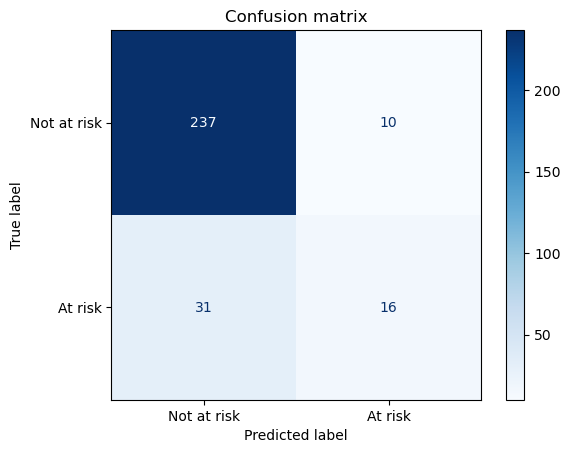

False Positives (false alarms): 10
False Negatives (missed cases): 31


In [65]:
#Classification Report
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not at risk','At risk'])
disp.plot(cmap='Blues')
plt.title('Confusion matrix')
plt.show()

# Manual read:
# [TN  FP]   Top-left = correctly predicted negative
# [FN  TP]   Bottom-right = correctly predicted positive
# FP = false alarm  |  FN = missed case (most dangerous in ops)

print(f"False Positives (false alarms): {cm[0,1]}")
print(f"False Negatives (missed cases): {cm[1,0]}")

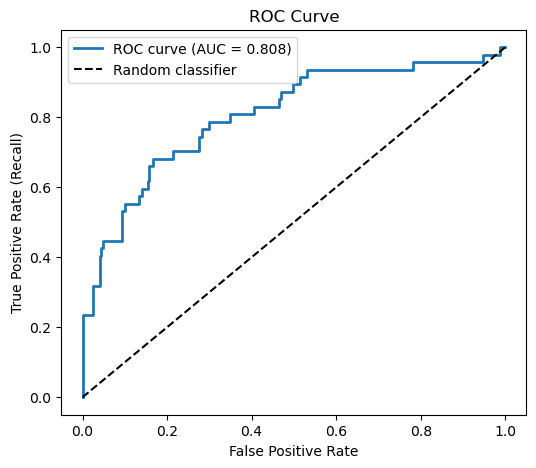

In [66]:
# ROC - AUC
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.3f})', lw=2)
plt.plot([0,1],[0,1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(); plt.show()

In [ ]:
# Multiclass Classification
from sklearn.metrics import classification_report

# Use average='macro' for equal weight per class (good if all classes matter equally)
# Use average='weighted' for weight by class size (good if class sizes vary a lot)
print(classification_report(y_test, y_pred, target_names=['Low','Medium','High','Critical']))
print(f"Macro F1:    {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(y_test, y_pred, average='weighted'):.4f}")

In [ ]:
# Regression Evaluation
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
    r2_score, explained_variance_score)

y_pred = best_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)
evs  = explained_variance_score(y_test, y_pred)

print(f"MAE:  {mae:.3f}   (avg absolute error in original units)")
print(f"MSE:  {mse:.3f}   (penalises large errors more)")
print(f"RMSE: {rmse:.3f}  (same units as target, more interpretable than MSE)")
print(f"R²:   {r2:.3f}    (1.0 = perfect, 0.0 = predicts mean, <0 = worse than mean)")
print(f"EVS:  {evs:.3f}   (similar to R², measures variance explained)")

# Plot predicted vs actual
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual'); plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

In [ ]:
# Residual Analysis 

residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted'); plt.ylabel('Residual')
plt.title('Residual plot')
plt.show()
# Residuals should be randomly scattered around 0
# If there's a pattern → your model is missing something (non-linearity, missing feature)

* Model Deployment

In [68]:
import pickle
import joblib

# Pickle — simple, works for any Python object
with open('model.pkl', 'wb') as f:
    pickle.dump(rs_log, f)

# Load back
with open('model.pkl', 'rb') as f:
    model = pickle.load(f)

# Joblib — better for large numpy arrays (sklearn models)
# joblib.dump(rs_log, 'model.joblib')
# model = joblib.load('model.joblib')

# If you used a Pipeline, save the whole pipeline (includes scaler + encoder)
# joblib.dump(full_pipeline, 'pipeline.joblib')